# NYC Uber Rides: Exploratory Data Analysis (EDA)


**Sections:**
1. Setup — import libraries, load the data
2. First look — inspect the raw data before touching it
3. Cleaning — fix the data problems
4. Q1–Q8 — the assigned questions
5. Summary and export


## 1. Setup

###Import the libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')            # global look: white background with light grid lines
plt.rcParams['figure.figsize'] = (9, 5)     # default plot size in inches (width, height)
os.makedirs('plots', exist_ok=True)         # make a folder called 'plots'; exist_ok=True means "no error if it already exists"

def save_show(name):
    plt.tight_layout()                                              # stop titles/labels from overlapping
    plt.savefig(f'plots/{name}.png', dpi=150, bbox_inches='tight')
    plt.show()                                                      # display the figure under the cell

## 2. First look at the raw data

 **look before you touch.** keep an untouched copy called raw to compare before and after cleaning.

In [8]:

raw = pd.read_csv("final_internship_data.csv")
df = raw.copy()                     # make a working copy

print('Shape (rows, columns):', df.shape)
df.head()

Shape (rows, columns): (500000, 26)


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,500000.0,11.358361,9.916617,-44.900000,6.000000,8.500000,12.500000,500.000000
pickup_longitude,500000.0,-1.265712,0.206941,-52.119764,-1.291405,-1.291226,-1.290970,37.360538
pickup_latitude,500000.0,0.696740,0.140909,-54.389440,0.710958,0.711268,0.711520,29.724576
dropoff_longitude,499995.0,-1.265755,0.205903,-59.049665,-1.291393,-1.291197,-1.290908,0.712985
dropoff_latitude,499995.0,0.696675,0.128997,-44.676047,0.710943,0.711277,0.711538,7.061893
passenger_count,500000.0,1.683428,1.307395,0.000000,1.000000,1.000000,2.000000,6.000000
hour,500000.0,13.510834,6.511571,0.000000,9.000000,14.000000,19.000000,23.000000
day,500000.0,15.684206,8.681066,1.000000,8.000000,16.000000,23.000000,31.000000
month,500000.0,6.268650,3.437815,1.000000,3.000000,6.000000,9.000000,12.000000
weekday,500000.0,3.042008,1.949240,0.000000,1.000000,3.000000,5.000000,6.000000



- fare_amount has a **negative minimum** and a **maximum of $500**
- pickup_longitude/latitude has -1.28 and 0.71 — these are NYC coordinates stored in **radians**, not degrees.
- Some coordinates are exactly 0 or far from NYC so this means that the GPS has bad rows.
- passenger_count includes 0.

In [11]:
missing = df.isna().sum()           # for each column: how many cells are empty
print(missing[missing > 0])         # show only the columns that actually have missing values
print()
for col in ['Car Condition', 'Weather', 'Traffic Condition']:
    print(col, '->', df[col].value_counts().to_dict())          # count of rides per category

dropoff_longitude    5
dropoff_latitude     5
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

Car Condition -> {'Very Good': 125312, 'Bad': 124978, 'Good': 124968, 'Excellent': 124742}
Weather -> {'sunny': 100433, 'cloudy': 100062, 'rainy': 99972, 'stormy': 99955, 'windy': 99578}
Traffic Condition -> {'Congested Traffic': 166847, 'Dense Traffic': 166584, 'Flow Traffic': 166569}


## 3. Data cleaning



In [12]:
df.columns = (df.columns
              .str.strip()                  # removes wrong spaces at the start/end of each column name
              .str.lower()                  # make all names lowercase
              .str.replace(' ', '_'))


df = df.rename(columns={'day': 'day_of_month', 'weekday': 'day_of_week'})

cleaning_log = []                   # an empty list; every cleaning step will add one entry here

def apply_filter(data, keep_mask, step_name):
    before = len(data)
    data = data[keep_mask]
    removed = before - len(data)
    cleaning_log.append({'step': step_name, 'rows_removed': removed, 'rows_left': len(data)})
    return data

###IDs, duplicates and missing values

key is a unique ID, used only for deduplication. user_id , user_name , driver_name carry no information about the fare, so  dont use them. Also, Rows with missing dropoff coordinates cannot be used for distance or location questions because only 5 rows are affected.

In [13]:
df = apply_filter(df, ~df['key'].duplicated(), 'Duplicate trip key')       # duplicated() marks repeats as True; ~ flips it, so we KEEP the first copy only
df = df.drop(columns=['user_id', 'user_name', 'driver_name', 'key'])       # remove identifier columns; they carry no information about price
df = apply_filter(df, df.notna().all(axis=1), 'Missing values')            # notna() = True where a cell has data; all(axis=1) = True only if the WHOLE row is complete

###Fixing the units (radians to degrees)

Coordinates are stored in radians. Any map, needs degrees.

In [14]:
coord_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']   # the four location columns, all in radians
df[coord_cols] = np.degrees(df[coord_cols])                 # np.degrees converts radians -> degrees for all four columns at once
df[coord_cols].describe().T[['min', 'max']]

,min,max
pickup_longitude,-2986.242495,2140.601160
pickup_latitude,-3116.285383,1703.092772
dropoff_longitude,-3383.296608,40.851027
dropoff_latitude,-2559.748913,404.616667


### Removing impossible rows

| Rule | Why |
|---|---|
| Pickup and dropoff inside NYC (lon −74.3 to −73.7, lat 40.5 to 41.0) | Rows at 0,0 or in the ocean are GPS errors |
| Fare between 2.50 and 100 | NYC's minimum fare was 2.50 negative or 500 fares are errors |
| 1 to 6 passengers | 0 passengers is not a ride|
| Distance at least 0.05 km (50 m) | Pickup or dropoff means no real trip, and it breaks fare-per-km maths later |

In [15]:
in_nyc = (df['pickup_longitude'].between(-74.3, -73.7) &     # between(a, b) is True when a <= value <= b
          df['pickup_latitude'].between(40.5, 41.0) &        # & means AND: every condition must hold
          df['dropoff_longitude'].between(-74.3, -73.7) &
          df['dropoff_latitude'].between(40.5, 41.0))
df = apply_filter(df, in_nyc, 'Coordinates outside NYC')     # keep only rides whose pickup AND dropoff are inside the box
df = apply_filter(df, df['fare_amount'].between(2.5, 100), 'Fare outside $2.50-$100')     # remove negative, tiny and extreme fares
df = apply_filter(df, df['passenger_count'].between(1, 6), 'Passengers not in 1-6')       # remove 0-passenger rows
df = apply_filter(df, df['distance'] >= 0.05, 'Distance under 50 m')                      # remove rides that did not go anywhere

###New columns

The airport-distance columns in the file (jfk_dist, lga_dist, ewr_dist) turn out to be **double** the true distance, so I will use the haversine formula and use that for Q8.

In [16]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distance in km between two points on Earth (works on whole columns at once)."""
    R = 6371.0                                                  # average radius of the Earth in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)             # trigonometry needs radians, so convert both latitudes
    dphi = phi2 - phi1                                          # difference in latitude
    dlmb = np.radians(lon2 - lon1)                              # difference in longitude, in radians
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlmb / 2) ** 2   # the haversine formula
    return 2 * R * np.arcsin(np.sqrt(a))                        # turn the angle into a distance along the surface

df['jfk_km'] = haversine_km(df['pickup_latitude'], df['pickup_longitude'], 40.6413, -73.7781)   # true distance from pickup to JFK
df['fare_per_km'] = df['fare_amount'] / df['distance']                                          # price paid per kilometre (safe: distance >= 0.05)

###Cleaning summary

In [17]:
log_df = pd.DataFrame(cleaning_log)                                     # turn the list of dictionaries into a table
print(f'Rows before cleaning: {len(raw):,}')
print(f'Rows after cleaning : {len(df):,}  ({len(df) / len(raw):.1%} of the data kept)')
log_df

Rows before cleaning: 500,000
Rows after cleaning : 479,944  (96.0% of the data kept)


,step,rows_removed,rows_left
0,Duplicate trip key,0,500000
1,Missing values,5,499995
2,Coordinates outside NYC,10999,488996
3,Fare outside $2.50-$100,140,488856
4,Passengers not in 1-6,1753,487103
5,Distance under 50 m,7159,479944


## 4. Questions



### Q1. Is higher passenger count associated with a higher price?

**Which plot, and why:** passenger_count only takes 6 whole-number values, so a **scatter plot** will draw the points in 6 vertical stripes. A **boxplot** of fare for each passenger count is more appropriate here: it summarises the fare distribution per group , the scatter shows the raw relationship, and the boxplot shows the comparison clearly.

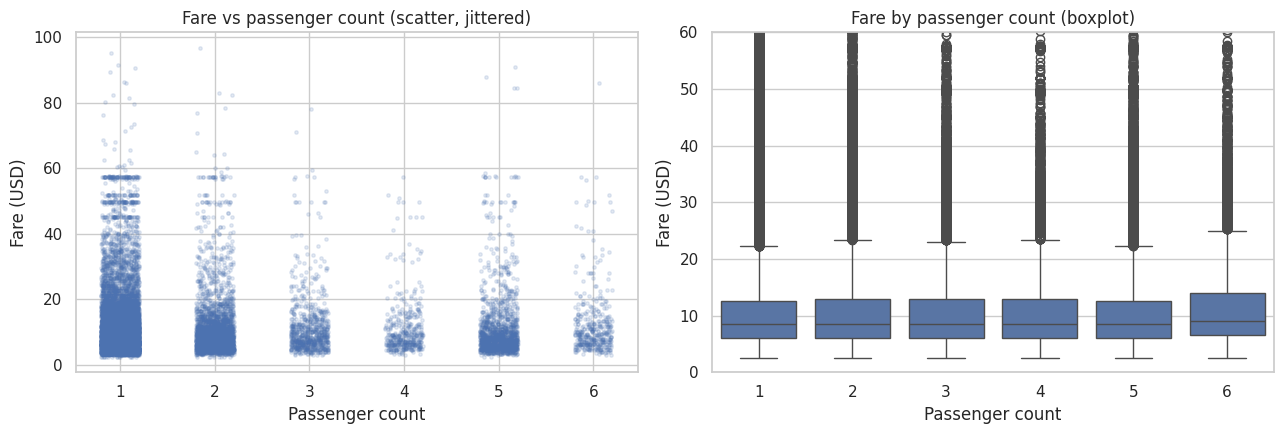

In [18]:
sample = df.sample(20000, random_state=42)          # 20,000 random rides for the scatter, so it isn't slow
jitter = np.random.uniform(-0.2, 0.2, size=len(sample))   # small random shift so points at the same passenger_count don't sit in one line

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(sample['passenger_count'] + jitter, sample['fare_amount'], s=6, alpha=0.15)   # x = passengers (jittered), y = fare
axes[0].set_title('Fare vs passenger count (scatter, jittered)')
axes[0].set_xlabel('Passenger count')
axes[0].set_ylabel('Fare (USD)')

sns.boxplot(data=df, x='passenger_count', y='fare_amount', ax=axes[1])
axes[1].set_ylim(0, 60)                             # zoom in; a handful of $100 outliers would squash the boxes otherwise
axes[1].set_title('Fare by passenger count (boxplot)')
axes[1].set_xlabel('Passenger count')
axes[1].set_ylabel('Fare (USD)')

save_show('q1_passenger_vs_fare')


**Interpretation:** the scatter is a flat cloud with no visible upward trend, and the boxplots sit at almost the same height for every passenger count. **No, a higher passenger count is not associated with a meaningfully higher fare.** The fare depends on the trip (distance, time) not on how many people are in the car.


### Q2. Does car condition influence the fare amount?

**Which plot, and why:** comparing a number across categories is a **bar chart** or a **boxplot**.The bar chart for a quick comparison of averages, and a boxplot to check whether the full distributions differ.

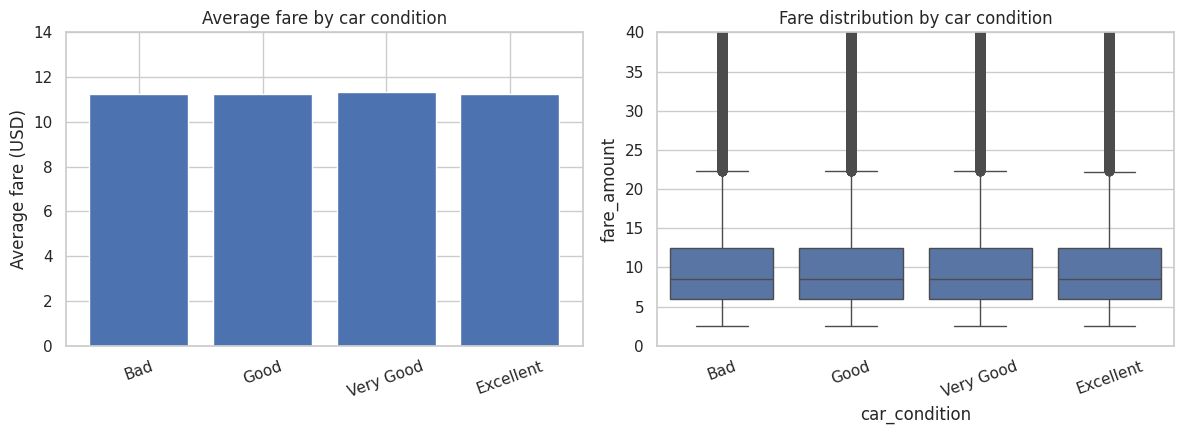

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

means = df.groupby('car_condition')['fare_amount'].mean().reindex(['Bad', 'Good', 'Very Good', 'Excellent'])   # average fare per category
axes[0].bar(means.index, means.values)              # one bar per category
axes[0].set_ylim(0, 14)                             # start at 0
axes[0].set_title('Average fare by car condition')
axes[0].set_ylabel('Average fare (USD)')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='car_condition', y='fare_amount',
            order=['Bad', 'Good', 'Very Good', 'Excellent'], ax=axes[1])
axes[1].set_ylim(0, 40)                             # zoom in
axes[1].set_title('Fare distribution by car condition')
axes[1].tick_params(axis='x', rotation=20)          # tilt labels

save_show('q2_car_condition_vs_fare')


**Interpretation:** the bars are almost the same height and the boxes overlap almost completely. **No, car condition does not meaningfully influence the fare.** Uber's pricing here does not appear to charge more for a nicer car.

### Q3. At what hour of the day are fares typically highest?

**Which plot, and why:** a **line plot** is the right choice because the x-axis (hour) is ordered,a bar chart would work too, but a line better shows the shape of the trend.

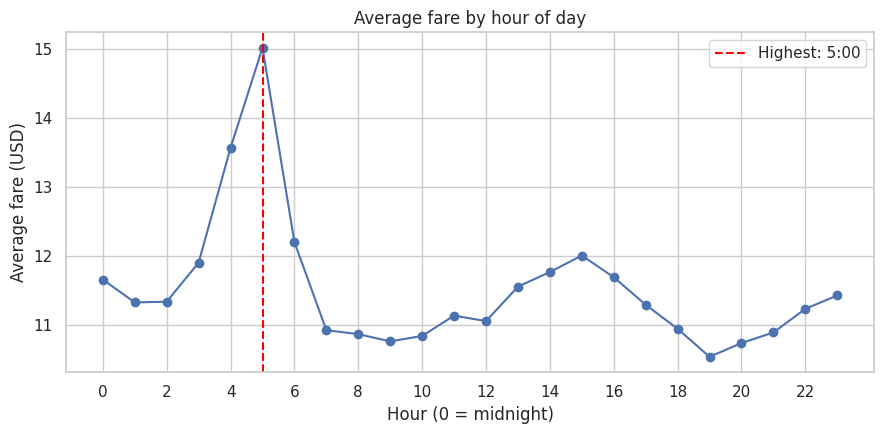

hour
5    15.02
4    13.57
6    12.20
Name: fare_amount, dtype: float64


In [20]:
by_hour = df.groupby('hour')['fare_amount'].mean()

plt.figure(figsize=(9, 4.5))
plt.plot(by_hour.index, by_hour.values, marker='o')         # line with a dot at each hour
plt.axvline(by_hour.idxmax(), color='red', linestyle='--',  # vertical dashed red line at the peak hour
            label=f'Highest: {by_hour.idxmax()}:00')        # f-string builds the legend label from the actual peak hour
plt.title('Average fare by hour of day')
plt.xlabel('Hour (0 = midnight)')
plt.ylabel('Average fare (USD)')
plt.xticks(range(0, 24, 2))                                  # show every second hour
plt.legend()                                                 # show the red line's label
save_show('q3_fare_by_hour')

print(by_hour.sort_values(ascending=False).head(3).round(2))

**Interpretation:** fares are highest in the very early morning, at 5 AM, with 4 AM  and 6 AM close behind.It is not caused by a higher price per km; per-km rates are actually lowest around that time.

### Q4. Does traffic condition affect the trip fare?

**Which plot, and why:** same reasoning as Q2 a **bar chart** of the average, backed up by a **boxplot**. If traffic really slowed rides down without changing the fare formula we would expect Congested to have a noticeably higher average.

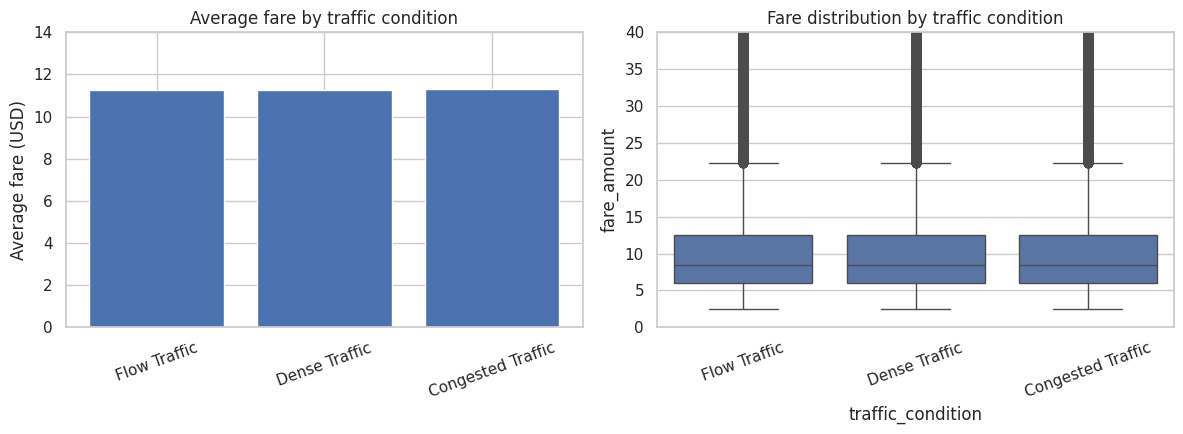

traffic_condition
Flow Traffic         11.24
Dense Traffic        11.26
Congested Traffic    11.30
Name: fare_amount, dtype: float64


In [21]:
order = ['Flow Traffic', 'Dense Traffic', 'Congested Traffic']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

means = df.groupby('traffic_condition')['fare_amount'].mean().reindex(order)   # average fare per traffic level
axes[0].bar(means.index, means.values)              # one bar per level
axes[0].set_ylim(0, 14)
axes[0].set_title('Average fare by traffic condition')
axes[0].set_ylabel('Average fare (USD)')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='traffic_condition', y='fare_amount', order=order, ax=axes[1])
axes[1].set_ylim(0, 40)
axes[1].set_title('Fare distribution by traffic condition')
axes[1].tick_params(axis='x', rotation=20)

save_show('q4_traffic_vs_fare')
print(means.round(2))

**Interpretation:** No, rides during heavy traffic do not have meaningfully higher fares than normal traffic in this data

### Q5. Is trip distance the strongest predictor of the fare amount?

**Which plot, and why:** a **scatter plot** is exactly right it shows both the direction and the shape of the relationship.

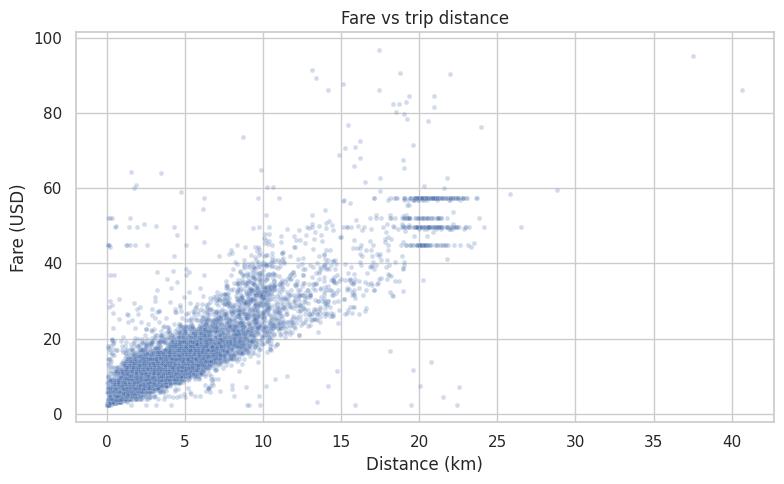

distance           0.900
jfk_km            -0.457
year               0.124
hour              -0.020
passenger_count    0.017
Name: fare_amount, dtype: float64


In [22]:
sample = df.sample(20000, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x='distance', y='fare_amount', alpha=0.25, s=12)   # x = km, y = fare, see-through points
plt.title('Fare vs trip distance')
plt.xlabel('Distance (km)')
plt.ylabel('Fare (USD)')
save_show('q5_distance_vs_fare')

num_cols = ['distance', 'passenger_count', 'hour', 'jfk_km', 'year']       # the other numeric candidates to compare against
corr_with_fare = df[num_cols + ['fare_amount']].corr()['fare_amount'].drop('fare_amount')   # correlation of each with fare
print(corr_with_fare.sort_values(key=abs, ascending=False).round(3))

**Interpretation:** the scatter shows a clear, almost straight upward line , as distance grows, fare grows with it. **Yes, distance is by far the strongest predictor of fare** in this dataset.

### Q6. At what time of day are ride requests most frequent?


**Which plot, and why:** this is a **count**, not an average, so it is a **count plot / bar chart**. We use bars because hour is a discrete bucket.

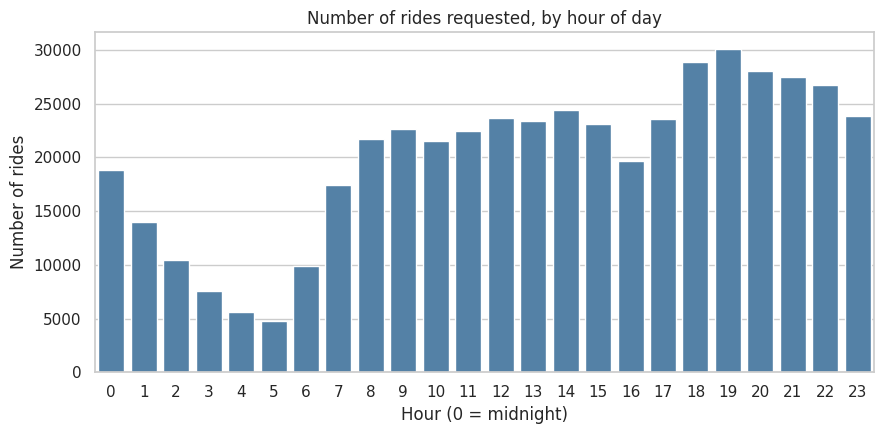

Busiest hours:
hour
19    30148
18    28882
20    28091
dtype: int64
Quietest hours:
hour
5    4727
4    5572
3    7562
dtype: int64


In [23]:
plt.figure(figsize=(9, 4.5))
sns.countplot(data=df, x='hour', color='steelblue')
plt.title('Number of rides requested, by hour of day')
plt.xlabel('Hour (0 = midnight)')
plt.ylabel('Number of rides')
save_show('q6_rides_by_hour')

rides_by_hour = df.groupby('hour').size()               # exact ride count per hour
print('Busiest hours:')
print(rides_by_hour.sort_values(ascending=False).head(3))    # top 3 busiest hours
print('Quietest hours:')
print(rides_by_hour.sort_values().head(3))

**Interpretation:** ride requests peak in the **evening**, highest at 7 PM, followed by 6 PM and 8 PM. They are lowest overnight, around 5 AM which is the same hour that had the highest average fare in Q3. So the hour with the most expensive average ride is also the quietest hour of the day.

### Q7. Does weather condition influence the average trip distance?

**Which plot, and why:** comparing an average across categories again calls for a **bar chart**, backed up by a **boxplot** to check the full spread, not only the mean (the same reasoning as Q2 and Q4)

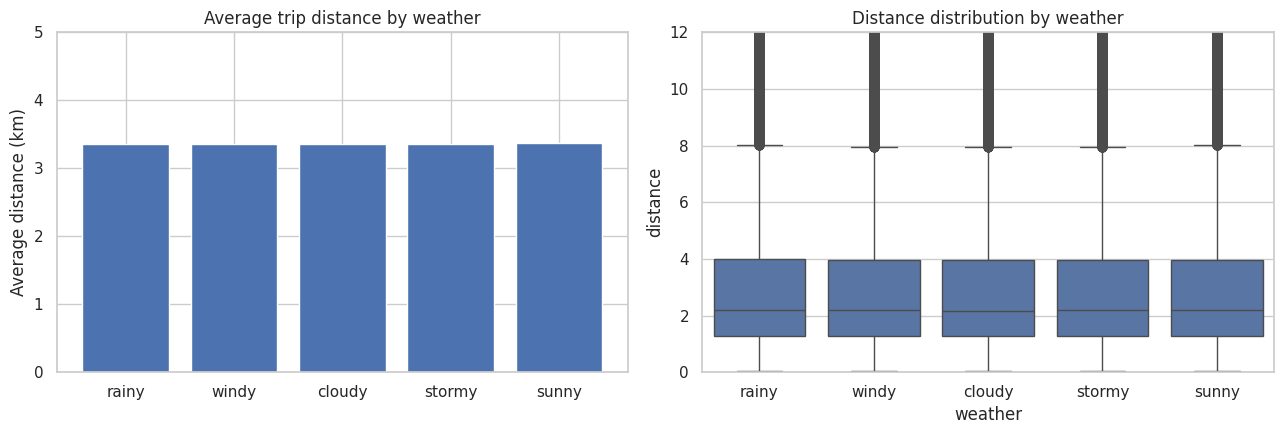

weather
rainy     3.36
windy     3.36
cloudy    3.36
stormy    3.36
sunny     3.37
Name: distance, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

means = df.groupby('weather')['distance'].mean().sort_values()   # average distance per weather condition, sorted low to high
axes[0].bar(means.index, means.values)              # one bar per weather condition
axes[0].set_ylim(0, 5)                              # tight range so small differences aren't a problem
axes[0].set_title('Average trip distance by weather')
axes[0].set_ylabel('Average distance (km)')

sns.boxplot(data=df, x='weather', y='distance', order=means.index, ax=axes[1])
axes[1].set_ylim(0, 12)
axes[1].set_title('Distance distribution by weather')

save_show('q7_weather_vs_distance')
print(means.round(2))

**Interpretation:** average trip distance is flat across weather conditions and the boxplots overlap almost exactly. **No, weather condition does not influence trip distance** in this data. Combined with Q2 and Q4, none of weather, car_condition, or traffic_condition` shows an effect on price or distance.

### Q8. Are rides that start closer to airports generally more expensive?


**Which plot, and why:** a **scatter plot** is the choice for two numeric variables, exactly as in Q5. I will add a categorical view (near-airport vs. not) as a second, complementary plot — this is a case where "more than one valid answer" clearly applies, since a scatter alone would bury the airport cluster among the much larger non-airport cloud.

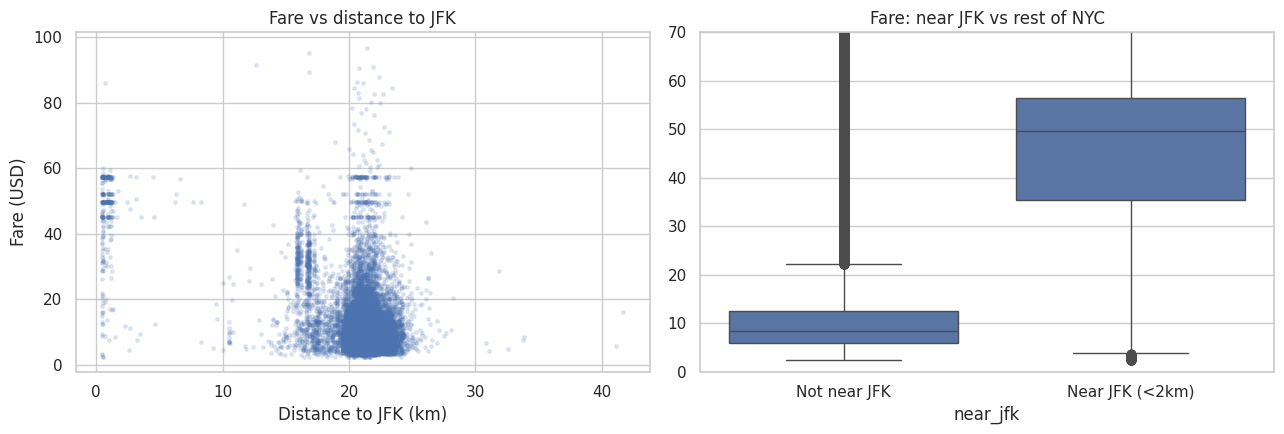

Correlation (distance to JFK, fare): -0.457
near_jfk
False    10.8
True     43.7
Name: fare_amount, dtype: float64


In [25]:
sample = df.sample(20000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(sample['jfk_km'], sample['fare_amount'], s=6, alpha=0.15)   # x = distance to JFK, y = fare
axes[0].set_title('Fare vs distance to JFK')
axes[0].set_xlabel('Distance to JFK (km)')
axes[0].set_ylabel('Fare (USD)')

df['near_jfk'] = df['jfk_km'] < 2                     # True if pickup is within 2 km of JFK
sns.boxplot(data=df, x='near_jfk', y='fare_amount', ax=axes[1])   # compare fare for near-JFK vs everyone else
axes[1].set_xticks([0, 1])                              # fix the tick positions before relabeling them
axes[1].set_xticklabels(['Not near JFK', 'Near JFK (<2km)'])
axes[1].set_ylim(0, 70)
axes[1].set_title('Fare: near JFK vs rest of NYC')
axes[1].set_ylabel('')                                   # no repeated y label

save_show('q8_airport_proximity_vs_fare')
print('Correlation (distance to JFK, fare):', round(df['jfk_km'].corr(df['fare_amount']), 3))
print(df.groupby('near_jfk')['fare_amount'].mean().round(2))

**Interpretation:** the correlation between distance-to-JFK and fare is about **−0.46**: the *closer* a pickup is to JFK, the *higher* the fare tends to be. The scatter shows a cluster of flat fares at very low jfk_km. The boxplot confirms it directly pickups within 2 km of JFK average about 44 dollars ,but about 10 dollars for the rest of NYC. **Yes, rides that start closer to an airport are generally more expensive**.

### Q9. Which numeric features correlate most strongly with fare?

Plot choice: correlation heatmap, this compares many numeric variables against fare at once, faster than eight separate scatter plots, but it only catches straight-line relationships.

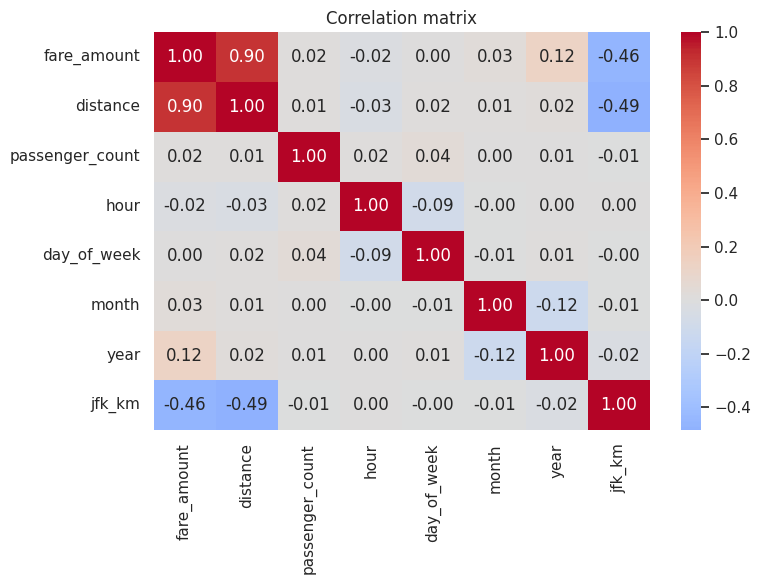

distance           0.900
jfk_km            -0.457
year               0.124
month              0.026
hour              -0.020
passenger_count    0.017
day_of_week        0.004
Name: fare_amount, dtype: float64


In [26]:
num_cols = ['fare_amount', 'distance', 'passenger_count', 'hour',
            'day_of_week', 'month', 'year', 'jfk_km']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)   # annot=True prints the number in each cell; center=0 makes 0 white
plt.title('Correlation matrix')
save_show('q12_correlation_heatmap')
print(corr['fare_amount'].drop('fare_amount').sort_values(key=abs, ascending=False).round(3))   # fare's correlation with each other column, strongest first

**Interpretation**: distance dominates, jfk_km is a distant second, and year is third .Passenger count, hour, day of week, month, sits below 0.03,so no linear relationship.

## 5. Summary


 Q1: No, passenger count has almost no effect on fare

 Q2: No, car condition changes the average fare

 Q3: 5 AM has the highest average fare

 Q4: No, traffic condition changes the average fare

 Q5: Yes, distance is by far the strongest predict

 Q6: 7 PM has the most ride requests and 5 AM has the fewest

 Q7: No, weather does not change the average trip distance

 Q8: Yes, pickups near JFK average about 44 vs about 10 elsewhere


**Pattern across Q2, Q4 and Q7:** none of car_condition, traffic_condition, or weather shows a real effect on fare or distance.